
# Sarcasm Detection Tutorial — CSV to Evaluation (CNN fallback-ready)
# Oleh: M. Imam Iryunullah && Muhammad Azmi Nur Iman


In [1]:
import os, sys, random, pandas as pd, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Matplotlib version:", plt.matplotlib.__version__)

Python: 3.12.5 | packaged by conda-forge | (main, Aug  8 2024, 18:24:51) [MSC v.1940 64 bit (AMD64)]
Matplotlib version: 3.10.6


In [2]:
import pandas as pd
import random
import textwrap

random.seed(42)

# === 1. Daftar kutipan / potongan teks Wayang (contoh dari kisah Gandawardaya) ===
wayang_texts = [
    """Di Kerajaan Hastina, Prabu Duryudana dihadap Patih Sangkuni, Danghyang Druna, dan Adipati Karna. 
    Patih Sangkuni melaporkan tentang seorang pemuda bernama Bambang Gandawardaya yang sangat sakti.""",
    
    """Patih Sangkuni menipu Bambang Gandawardaya dengan mengatakan bahwa ayah kandungnya adalah Prabu Duryudana, 
    padahal sebenarnya Raden Premadi adalah nama lain dari Raden Arjuna.""",

    """Raden Gandawardaya menyerang Kerajaan Amarta atas perintah Prabu Duryudana, 
    dan berhasil menaklukkan Arya Wrekodara, Raden Antareja, serta Raden Gatutkaca.""",

    """Dewi Grantangsasi, istri Raden Gandawardaya, ditinggal suaminya dan dirayu oleh Raden Lesmana Mandrakumara, 
    namun ia menolak dan menggunakan aji sirep untuk melarikan diri dari istana.""",

    """Raden Gandakusuma, putra Arjuna dan Dewi Gandawati, berpamitan kepada ibunya untuk mencari ayah kandungnya di Kerajaan Amarta.""",

    """Pertarungan hebat terjadi antara Raden Gandakusuma dan Raden Gandawardaya, 
    hingga akhirnya mereka sadar bahwa keduanya adalah saudara seayah.""",

    """Bagawan Wilawuk datang menjelaskan kebenaran bahwa Raden Arjuna adalah ayah dari kedua pemuda itu. 
    Semua kesalahpahaman pun berakhir dengan damai.""",

    """Prabu Kresna hadir sebagai penengah, memastikan agar Raden Gandawardaya menebus kesalahannya dengan membebaskan para Pandawa yang ditawan.""",

    """Setelah semua kebenaran terungkap, Raden Arjuna memeluk kedua putranya dan mengajak mereka tinggal di Indraprasta.""",

    """Dewi Grantangsasi bersyukur atas berakhirnya kesalahpahaman, 
    dan kisah Gandawardaya pun menjadi pelajaran tentang kesetiaan, tipu daya, dan pengampunan."""
]

# === 2. Tambahkan versi non-wayang (teks naratif biasa untuk pembanding) ===
non_wayang_texts = [
    "Hari ini cuaca sangat cerah dan langit berwarna biru.",
    "Aku sedang belajar membuat dataset teks untuk pelatihan model bahasa.",
    "Pemrograman Python sangat menyenangkan jika dipelajari dengan sabar.",
    "Banyak orang menyukai cerita fiksi karena mengandung nilai moral.",
    "Model pembelajaran mesin membutuhkan data yang seimbang antara dua kelas.",
    "Analisis teks dapat digunakan untuk memahami emosi dan topik dalam dokumen.",
    "Membaca kisah klasik bisa membantu memahami budaya dan sejarah masyarakat.",
    "Saya sedang menguji model klasifikasi teks menggunakan dataset buatan.",
    "Proyek ini bertujuan mengenali tema dalam cerita berdasarkan kata kunci.",
    "Dataset ini akan digunakan untuk percobaan NLP sederhana."
]

def generate_data(source_texts, label, count):
    rows = []
    for _ in range(count):
        txt = random.choice(source_texts)
        # Tambahkan variasi kecil agar dataset tidak terlalu repetitif
        txt = textwrap.shorten(txt + " " + random.choice(source_texts), width=random.randint(180, 350), placeholder="...")
        rows.append({"text": txt, "label": label})
    return rows

data_rows = []
data_rows += generate_data(wayang_texts, label=1, count=300)     # 300 teks wayang
data_rows += generate_data(non_wayang_texts, label=0, count=300) # 300 teks umum
random.shuffle(data_rows)



In [ ]:
df = pd.DataFrame(data_rows)
csv_path = "wayang_dataset.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")

print("Dataset berhasil dibuat!")
print("Path:", csv_path)
print("Jumlah data:", len(df))
df.sample(5, random_state=1)


✅ Dataset berhasil dibuat!
Path: wayang_dataset.csv
Jumlah data: 600


,text,label
446,"Raden Gandakusuma, putra Arjuna dan Dewi Ganda...",1
404,Pertarungan hebat terjadi antara Raden Gandaku...,1
509,Aku sedang belajar membuat dataset teks untuk ...,0
455,Bagawan Wilawuk datang menjelaskan kebenaran b...,1
201,Membaca kisah klasik bisa membantu memahami bu...,0


In [ ]:

from sklearn.model_selection import train_test_split

data = pd.read_csv("wayang_dataset.csv")

print("Shape:", data.shape)
print("Columns:", list(data.columns))
print("\nDistribusi label:\n", data["label"].value_counts())

X = data["text"].astype(str).values
y = data["label"].values

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n=== Hasil Pembagian Dataset ===")
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Shape: (600, 2)
Columns: ['text', 'label']

Distribusi label:
 label
1    300
0    300
Name: count, dtype: int64

=== Hasil Pembagian Dataset ===
Train size: 420
Validation size: 90
Test size: 90


In [12]:
use_tf = False
try:
    import tensorflow as tf
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    use_tf = True
    print("TensorFlow detected — CNN path will be used.")
except Exception as e:
    print("TensorFlow not available — using classical ML pipeline (TF-IDF + LogisticRegression).")

max_words = 5000
max_len = 30

if use_tf:
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_train)

    X_train_proc = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=max_len, padding="post", truncating="post")
    X_val_proc   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=max_len, padding="post", truncating="post")
    X_test_proc  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=max_len, padding="post", truncating="post")
    vocab_size = min(max_words, len(tokenizer.word_index) + 1)
    print("Vocab size:", vocab_size, "Max len:", max_len)
else:
    from sklearn.feature_extraction.text import TfidfVectorizer
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2), lowercase=True)
    X_train_proc = tfidf.fit_transform(X_train)
    X_val_proc   = tfidf.transform(X_val)
    X_test_proc  = tfidf.transform(X_test)
    print("TF-IDF features:", X_train_proc.shape)


TensorFlow detected — CNN path will be used.
Vocab size: 196 Max len: 30


In [13]:
if use_tf:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout

    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=64, input_shape=(max_len,)),  # gunakan input_shape, bukan input_length
        Conv1D(filters=128, kernel_size=3, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(64, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid")
    ])

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    # pastikan model dibangun (khusus beberapa versi TF)
    model.build(input_shape=(None, max_len))  # tambahkan ini jika tetap muncul 0 param
    model.summary()

else:
    from sklearn.linear_model import LogisticRegression
    model = LogisticRegression(max_iter=200)
    print(model)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,569 (178.00 KB)

 Trainable params: 45,569 (178.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = None

if use_tf:
    y_train_np = np.array(y_train)
    y_val_np   = np.array(y_val)
    history = model.fit(
        X_train_proc, y_train_np,
        validation_data=(X_val_proc, y_val_np),
        epochs=10,
        batch_size=32,
        verbose=1
    )
else:
    model.fit(X_train_proc, y_train)
    print("Training complete (classical ML).")


Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8857 - loss: 0.6153 - val_accuracy: 1.0000 - val_loss: 0.4722
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9976 - loss: 0.3559 - val_accuracy: 1.0000 - val_loss: 0.1697
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0989 - val_accuracy: 1.0000 - val_loss: 0.0247
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 0.0045
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss: 9.9969e-04
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - val_loss: 7.0818e-04
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 -

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Test Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        45
           1     1.0000    1.0000    1.0000        45

    accuracy                         1.0000        90
   macro avg     1.0000    1.0000    1.0000        90
weighted avg     1.0000    1.0000    1.0000        90

Confusion Matrix:
 [[45  0]
 [ 0 45]]


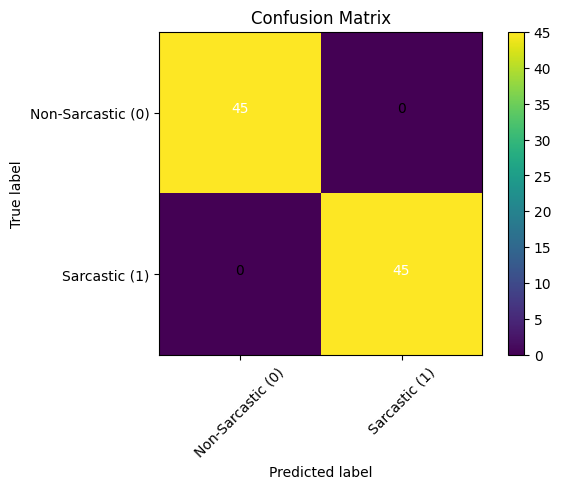

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

if use_tf:
    y_pred_prob = model.predict(X_test_proc).ravel()
    y_pred = (y_pred_prob >= 0.5).astype(int)
else:
    y_pred = model.predict(X_test_proc)

acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix (matplotlib, no seaborn)
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Non-Sarcastic (0)', 'Sarcastic (1)'], rotation=45)
plt.yticks(tick_marks, ['Non-Sarcastic (0)', 'Sarcastic (1)'])
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


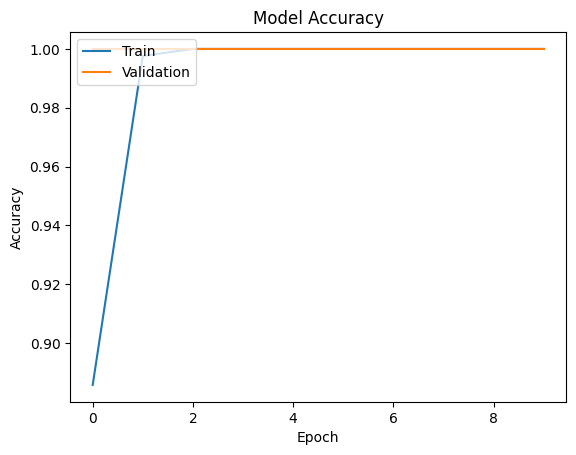

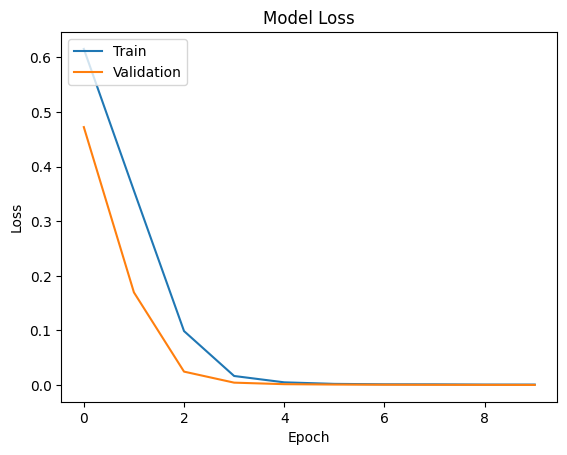

In [16]:
if use_tf and history is not None:
    # Accuracy
    plt.figure()
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title("Model Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")
    plt.show()

    # Loss
    plt.figure()
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title("Model Loss")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend(["Train", "Validation"], loc="upper left")
    plt.show()
else:
    print("Learning curves tersedia bila menggunakan TensorFlow (CNN).")


In [20]:
sentences = [
    "Putra bima melawan gandawardaya.",
    "Dewa shira membantai.",
    "Bagawan Wilawuk datang menjelaskan kebenaranBagawan Wilawuk datang menjelaskan kebenaran.",
    "Bener disini gandawardaya!"
]

if use_tf:
    seqs = [sent.split() for sent in sentences]  # only to inspect
    X_new = pad_sequences(tokenizer.texts_to_sequences(sentences), maxlen=30, padding="post", truncating="post")
    probs = model.predict(X_new).ravel()
    preds = (probs >= 0.5).astype(int)
else:
    X_new = tfidf.transform(sentences)
    preds = model.predict(X_new)

for s, p in zip(sentences, preds):
    print(f"{p}\t{s}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1	Putra bima melawan gandawardaya.
0	Dewa shira membantai.
0	Bagawan Wilawuk datang menjelaskan kebenaranBagawan Wilawuk datang menjelaskan kebenaran.
1	Bener disini gandawardaya!
